# Volatility & Correlation

This notebook estimates the volatility, covariance and correlation characteristics of the portfolio's constituent assets. These estimates form the foundation for portfolio risk measurement, particularly Parametric VaR and Monte Carlo VaR.

The analysis includes:

1. Historical volatility
2. Rolling volatility
3. Covariance matrix
4. Correlation matrix
5. EWMA volatility
6. Comparison of volatility methodologies

In [1]:

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices

In [3]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

In [4]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE
)

returns = prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


## 1. Historical Volatility

Historical volatility is estimated as the sample standard deviation of daily returns.

Annualized volatility = Daily SD * root (252)

In [7]:
daily_volatility = returns.std()
annualized_volatility = daily_volatility*np.sqrt(252)
volatility_table = pd.DataFrame({
    "Daily Volatility":daily_volatility,
    "Annualized Volatility" : annualized_volatility
})
volatility_table

,Daily Volatility,Annualized Volatility
Ticker,,
GLD,0.009290,0.147472
IWM,0.014195,0.225335
QQQ,0.013847,0.219817
SPY,0.011208,0.177925
TLT,0.009474,0.150397


In [ ]:

annualized_volatility

Ticker
GLD    0.147472
IWM    0.225335
QQQ    0.219817
SPY    0.177925
TLT    0.150397
dtype: float64

## 2. Rolling Volatility

Rolling volatility allows us to observe how the risk environment changes over time.
Taking a rolling window of 60

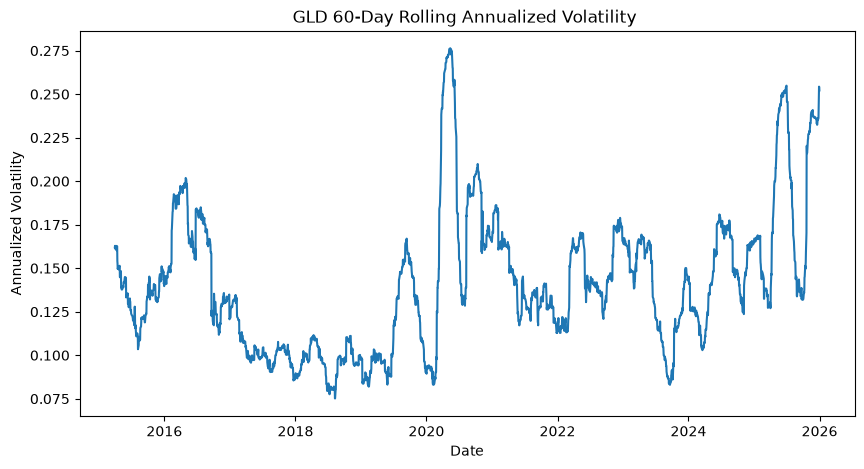

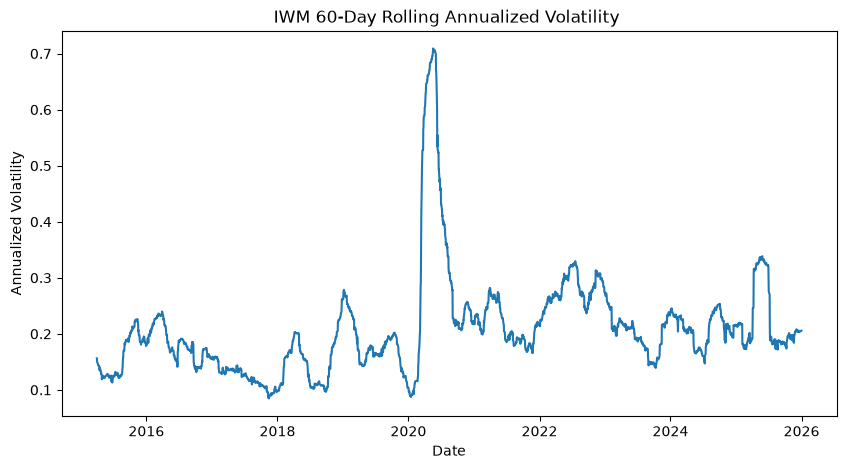

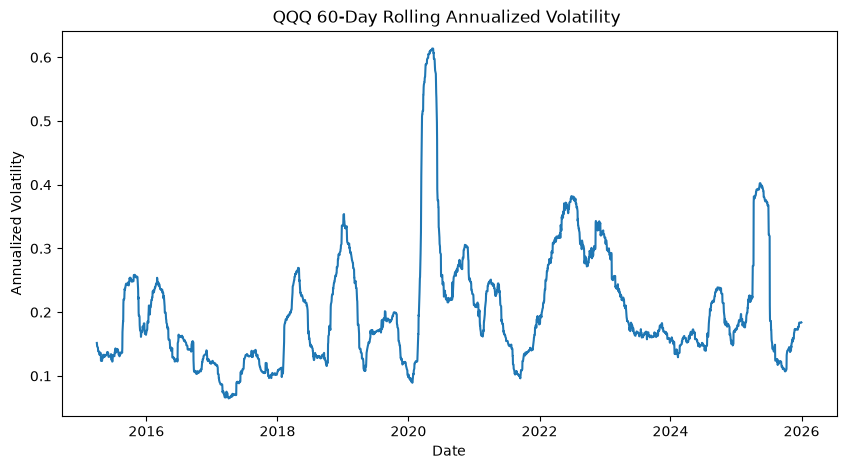

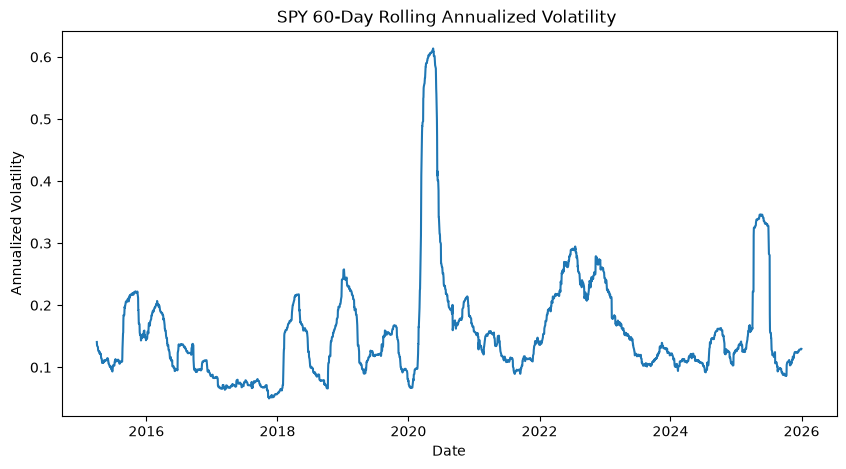

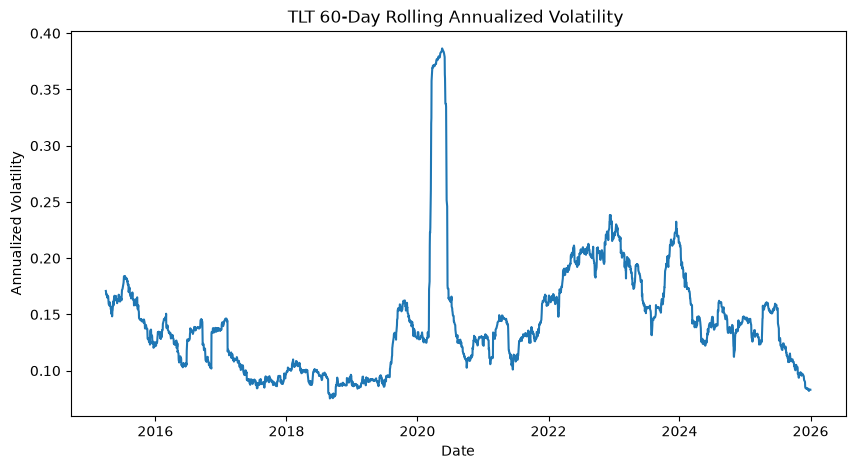

In [44]:
rolling_volatility_table = returns.rolling(window=60).std()

for ticker in returns.columns:
    plt.figure(figsize=(10,5))
    plt.plot(rolling_volatility_table[ticker]*np.sqrt(252))
    plt.title(f"{ticker} 60-Day Rolling Annualized Volatility "),
    plt.xlabel("Date"),
    plt.ylabel("Annualized Volatility")
    plt.show()

## 3. Covariance Matrix

The covariance matrix measures how asset returns move together.

The diagonal elements represent the variance of each asset, while the
off-diagonal elements represent pairwise covariance.

The covariance matrix is a key input to portfolio volatility:

σₚ = √(wᵀΣw)

where w represents portfolio weights and Σ represents the covariance matrix.

In [9]:
covariance_matrix = returns.cov()
covariance_matrix

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,0.000086,0.000006,0.000007,0.000005,0.000025
IWM,0.000006,0.000201,0.000151,0.000138,-0.000022
QQQ,0.000007,0.000151,0.000192,0.000145,-0.000017
SPY,0.000005,0.000138,0.000145,0.000126,-0.000020
TLT,0.000025,-0.000022,-0.000017,-0.000020,0.000090


In [10]:
annualized_covariance = covariance_matrix * 252
annualized_covariance

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,0.021748,0.001547,0.001693,0.001160,0.006232
IWM,0.001547,0.050776,0.038101,0.034770,-0.005535
QQQ,0.001693,0.038101,0.048320,0.036521,-0.004340
SPY,0.001160,0.034770,0.036521,0.031657,-0.004950
TLT,0.006232,-0.005535,-0.004340,-0.004950,0.022619


## 4. Correlation Matrix

Correlation standardizes covariance to a range between -1 and +1.

Unlike covariance, correlation is independent of the scale of the individual
assets and therefore makes it easier to compare relationships across assets.

In [11]:
correlation_matrix = returns.corr()
correlation_matrix

Ticker,GLD,IWM,QQQ,SPY,TLT
Ticker,,,,,
GLD,1.000000,0.046556,0.052230,0.044217,0.280960
IWM,0.046556,1.000000,0.769219,0.867230,-0.163326
QQQ,0.052230,0.769219,1.000000,0.933781,-0.131282
SPY,0.044217,0.867230,0.933781,1.000000,-0.184989
TLT,0.280960,-0.163326,-0.131282,-0.184989,1.000000


The correlation matrix **indicates substantial dependence among the equity assets. SPY, QQQ and IWM exhibit strong positive correlations**, with correlations of approximately 0.93, 0.77 and 0.87 across the relevant pairs.
This indicates that holding multiple equity ETFs does not necessarily provide proportionate diversification because the assets share significant common market risk.
TLT **exhibits mildly negative correlations with the equity assets, while GLD has relatively low correlation with SPY and QQQ.** These assets therefore have greater potential to provide diversification benefits within a multi-asset portfolio.

## 5. EWMA Volatility

Historical volatility assigns equal weight to observations across the estimation window. EWMA volatility gives greater weight to recent observations through an exponential decay factor.

The EWMA variance is calculated as:

σ²ₜ = λσ²ₜ₋₁ + (1 − λ)r²ₜ₋₁

A decay factor of λ = 0.94 is used for the initial implementation.

In [21]:
lambda_ = 0.94

ewma_table = pd.DataFrame(index=returns.index)

for ticker in returns.columns:

    variance_col = f"{ticker}_variance"
    volatility_col = f"{ticker}_annualized_volatility"

    # 1. Initialize columns with NaN
    ewma_table[variance_col] = np.nan
    ewma_table[volatility_col] = np.nan

    # 2. Get the column number positions 
    var_col_idx = ewma_table.columns.get_loc(variance_col)
    vol_col_idx = ewma_table.columns.get_loc(volatility_col)

    # 3. Initial variance estimate
    ewma_table.iat[0, var_col_idx] = returns[ticker].iloc[0] ** 2

    # 4. Initial annualized volatility 
    ewma_table.iat[0, vol_col_idx] = np.sqrt(
        ewma_table.iat[0, var_col_idx] * 252
    )

    # 5. EWMA recursion loop
    for i in range(1, len(returns[ticker])):

        # Single-step update for variance
        ewma_table.iat[i, var_col_idx] = (
            lambda_ * ewma_table.iat[i - 1, var_col_idx]
            + (1 - lambda_) * returns[ticker].iloc[i - 1] ** 2
        )

        # Single-step update for volatility
        ewma_table.iat[i, vol_col_idx] = np.sqrt(
            ewma_table.iat[i, var_col_idx] * 252
        )

ewma_table.tail()

,GLD_variance,GLD_annualized_volatility,IWM_variance,IWM_annualized_volatility,QQQ_variance,QQQ_annualized_volatility,SPY_variance,SPY_annualized_volatility,TLT_variance,TLT_annualized_volatility
Date,,,,,,,,,,
2025-12-24,0.000121,0.174840,0.000131,0.181738,0.000113,0.168577,0.000052,0.114976,0.000022,0.074330
2025-12-26,0.000115,0.170274,0.000124,0.176470,0.000107,0.163837,0.000050,0.112310,0.000023,0.075817
2025-12-29,0.000116,0.171217,0.000118,0.172241,0.000100,0.158846,0.000047,0.108889,0.000022,0.074615
2025-12-30,0.000223,0.237075,0.000113,0.168684,0.000096,0.155153,0.000045,0.106477,0.000022,0.073806
2025-12-31,0.000210,0.229870,0.000109,0.166060,0.000090,0.150697,0.000042,0.103343,0.000021,0.072156


## 6. Volatility Method Comparison

Different volatility estimators make different assumptions about how relevant historical observations are.

- Historical volatility assigns equal importance to observations across the   estimation sample.
- Rolling volatility uses a fixed recent window.
- EWMA volatility assigns exponentially declining weights to older observations.

Comparing these approaches helps assess how sensitive risk estimates are to the volatility methodology.

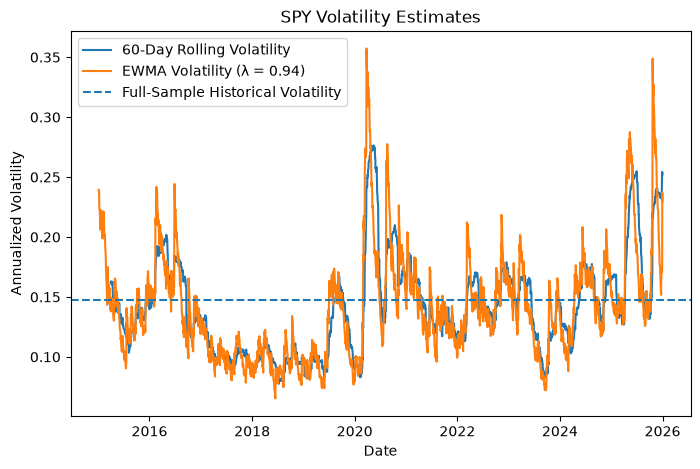

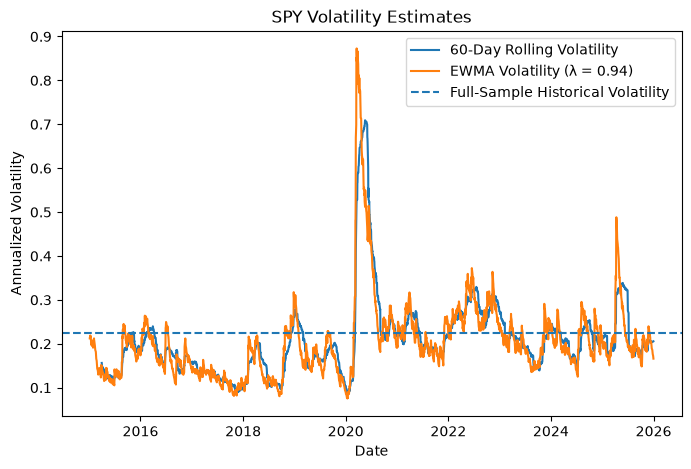

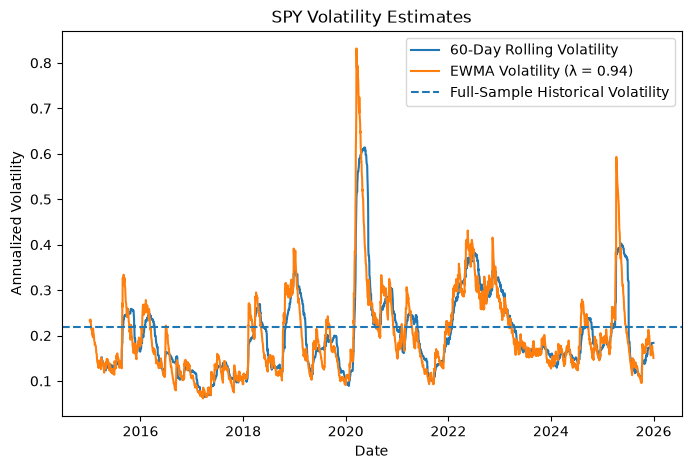

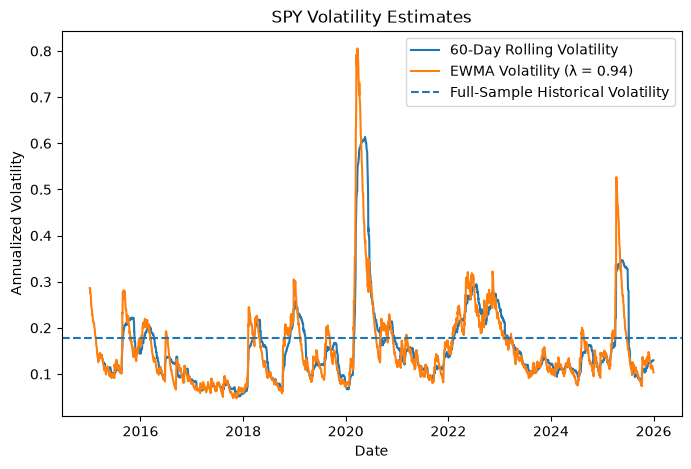

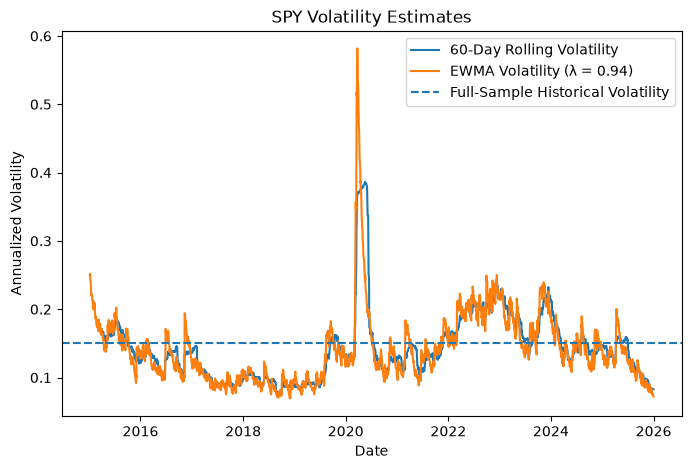

In [45]:
for ticker in returns.columns:
    plt.figure(figsize=(8,5))
    plt.plot(
        rolling_volatility_table[ticker] * np.sqrt(252),
        label="60-Day Rolling Volatility"
    )
    
    plt.plot(
        ewma_table[f"{ticker}_annualized_volatility"],
        label="EWMA Volatility (λ = 0.94)"
    )

    plt.axhline(
        y=annualized_volatility[ticker],
        linestyle="--",
        label="Full-Sample Historical Volatility"
    )
    
    plt.title("SPY Volatility Estimates")
    plt.xlabel("Date")
    plt.ylabel("Annualized Volatility")
    plt.legend()

    plt.show()

## Key Observations

The volatility estimates vary substantially depending on the estimation methodology.

Full-sample historical volatility remains constant because all observations receive equal weight. In contrast, both rolling volatility and EWMA volatility respond to changes in the market volatility regime.

EWMA volatility responds more quickly to recent return shocks because recent observations receive greater weight. The decay factor therefore determines how rapidly the estimated volatility adjusts to changing market conditions.

The choice of volatility estimator is consequently an important model assumption and can materially affect subsequent parametric VaR estimates.